In [93]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature
import xarray as xr
import numpy as np

## How to get a subset of Argo data for a heatwave

first load in our HW table from the ```MHW_list.csv``` file

In [152]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '../../MHW_list.csv'

dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = 'NA 2023'# 'NA 2023'  #'SWPac2023'

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 

date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

if hw == 'NA 2023':
    date0 = pd.to_datetime('2023-03-01')
    date1 = pd.to_datetime('2023-12-01')

print([lat0.item(), lat1.item(), lon0.item(), lon1.item(), date0, date1])


[10, 50, -60, -10, Timestamp('2023-03-01 00:00:00'), Timestamp('2023-12-01 00:00:00')]


## CrocoLake Access

## Warning - subset doesn't work yet if crossing 180deg line 

In [153]:
# Parameters
columns = ('PRES','TEMP','PSAL','DOXY','LATITUDE','LONGITUDE','JULD','CYCLE_NUMBER','DB_NAME')

# Check if lons cross 180
if lon0 > lon1:
    lon0_1, lon1_1 = lon0, 180
    lon0_2, lon1_2 = -180, lon1
    filters_1 = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0_1), ("LONGITUDE","<=",lon1_1),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    filters_2 = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0_2), ("LONGITUDE","<=",lon1_2),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    
    df_1 = pd.read_parquet(parquet_dir,columns=columns,filters=filters_1)
    df_2 = pd.read_parquet(parquet_dir,columns=columns,filters=filters_2)
    df = pd.concat([df_1, df_2], axis=0)

else:
    # without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
    filters = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0), ("LONGITUDE","<=",lon1),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    
    df = pd.read_parquet(parquet_dir,columns=columns,filters=filters)
df

,PRES,TEMP,PSAL,DOXY,LATITUDE,LONGITUDE,JULD,CYCLE_NUMBER,DB_NAME
0,0.0,27.077101,35.700401,205.32254,10.439708,-25.320283,2023-03-17 11:17:00,1,ARGO
1,0.1,27.077101,35.700401,205.792648,10.439708,-25.320283,2023-03-17 11:17:00,1,ARGO
2,0.2,27.077101,35.700401,204.382294,10.439708,-25.320283,2023-03-17 11:17:00,1,ARGO
3,0.27,27.077101,35.700401,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,ARGO
4,0.3,27.0753,35.700703,203.749939,10.439708,-25.320283,2023-03-17 11:17:00,1,ARGO
...,...,...,...,...,...,...,...,...,...
1743673,955.099976,6.612,34.948002,<NA>,19.136242,-23.708215,2023-03-27 11:30:00,75,ARGO
1743674,963.900024,6.585061,34.950695,113.47731,19.136242,-23.708215,2023-03-27 11:30:00,75,ARGO
1743675,964.900024,6.582,34.951,<NA>,19.136242,-23.708215,2023-03-27 11:30:00,75,ARGO
1743676,970.799988,6.554,34.950001,<NA>,19.136242,-23.708215,2023-03-27 11:30:00,75,ARGO


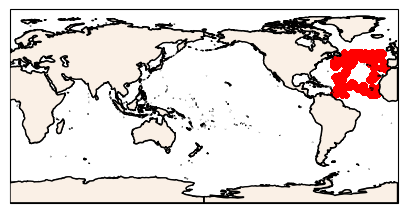

In [154]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='linen')
ax.set_global()

ax.scatter(df.LONGITUDE, df.LATITUDE, c='r', s=8, transform=ccrs.PlateCarree())

In [56]:
df.columns

Index(['PRES', 'TEMP', 'PSAL', 'DOXY', 'LATITUDE', 'LONGITUDE', 'JULD',
       'CYCLE_NUMBER', 'DB_NAME'],
      dtype='str')

In [24]:
bucket = 's3://uw-escience-scratch-prod'
mhw = xr.open_dataset(f'{bucket}/oisst/mhw_mask_north_atlantic_final.zarr', engine='zarr')['mhw_mask']

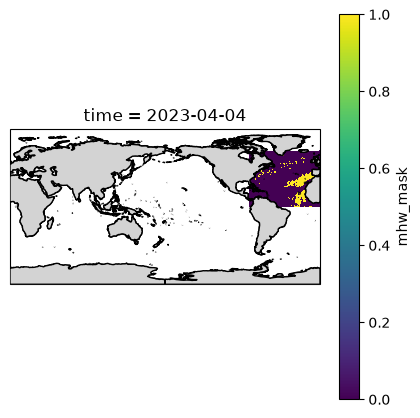

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='lightgray')
ax.set_global()
mhw.isel(time=15190).plot(ax=ax, transform=ccrs.PlateCarree())
plt.show()

# GOBAI

In [51]:
gobai = xr.open_dataset(f'{bucket}/team_mhw/GOBAI-O2-v2.3.nc', engine='h5netcdf')

In [52]:
gobai

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB ...
    uncer    (time, pres, lat, lon) float32 3GB ...
    temp     (time, pres, lat, lon) float32 3GB ...
    sal      (time, pres, lat, lon) float32 3GB ...

In [66]:
def convert_lons(da):
    da.coords['lon'] = (((360 + (da.lon % 360)) % 360))
    da_new_lon = da.sortby(da.lon)
    return da_new_lon

In [89]:
gobai_oxy = convert_lons(gobai['oxy'])
oxy = gobai_oxy.sel(lat=slice(lat0, lat1), lon=slice(150, 220))

In [97]:
weights = np.cos(np.deg2rad(oxy.lat))

In [98]:
oxy_area_mean = oxy.weighted(weights).mean(['lat', 'lon'])

In [108]:
oxy_area_mean_anom = oxy_area_mean.groupby('time.month') - oxy_area_mean.groupby('time.month').mean()

In [112]:
gobai_temp = convert_lons(gobai['temp'])
temp = gobai_temp.sel(lat=slice(lat0, lat1), lon=slice(150, 220))
temp_area_mean = temp.weighted(weights).mean(['lat', 'lon'])
temp_area_mean_anom = temp_area_mean.groupby('time.month') - temp_area_mean.groupby('time.month').mean()

In [138]:
mhw_depth = xr.where((temp_area_mean_anom.groupby('time.month') - temp_area_mean_anom.groupby('time.month').quantile(0.95))>=0, 1, 0)

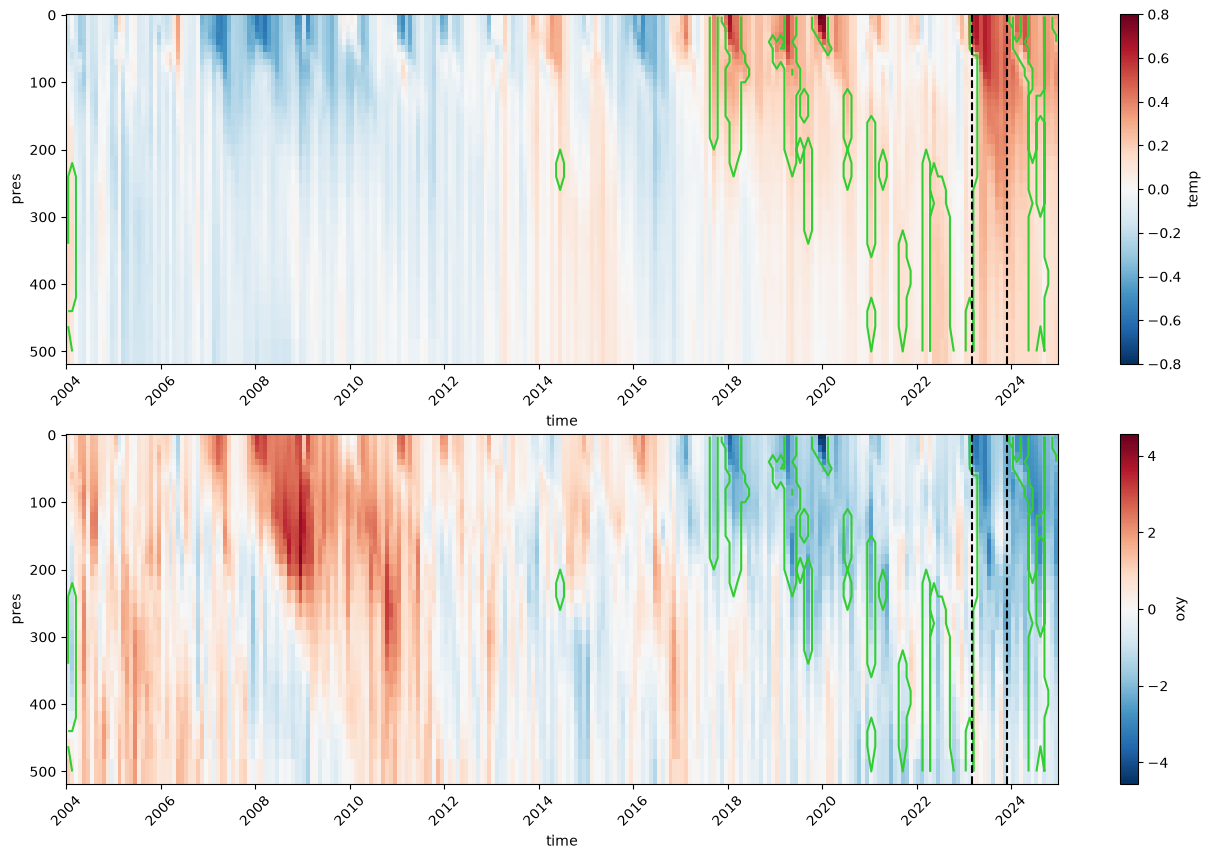

In [172]:
fig, axs = plt.subplots(2, 1, figsize=(16, 10))

ax = axs[0]
temp_area_mean_anom.sel(pres=slice(0, 500)).T.plot(ax=ax)
mhw_depth.sel(pres=slice(0, 500)).T.plot.contour(ax=ax, levels=[0], colors=['limegreen'])
# for date in df.JULD.dt.date.unique():
    # ax.axvline(date, c='yellow', ls=':', lw=0.5)
ax.invert_yaxis()
ax.tick_params(axis='x', labelrotation=45)
ax.axvline(date0, c='k', ls='--')
ax.axvline(date1, c='k', ls='--')
# plt.show()

# fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax = axs[1]
oxy_area_mean_anom.sel(pres=slice(0, 500)).T.plot(ax=ax)
mhw_depth.sel(pres=slice(0, 500)).T.plot.contour(ax=ax, levels=[0], colors=['limegreen'])
ax.invert_yaxis()
ax.tick_params(axis='x', labelrotation=45)
ax.axvline(date0, c='k', ls='--')
ax.axvline(date1, c='k', ls='--')
plt.show()